In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import warnings
warnings.filterwarnings("ignore")
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


**Loading Data**

In [2]:
train=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')

**Exploratory Data Analysis(EDA)**

In [3]:
train.shape

(198000, 15)

In [4]:
test.shape

(102000, 14)

In [5]:
 train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [6]:
train.head(2)

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0


In [7]:
train.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


In [8]:
train.isnull().sum()

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

In [9]:
train[train['comment'].isnull()==True]

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
99535,2024-04-18 06:40:48.161601+00:00,31,0,0,0,1,0,4,4,none,none,none,False,NaN,0


In [10]:
#Prints unique values 
for col in ['emoticon_1','emoticon_2','emoticon_3','upvote','downvote','if_1','if_2','race','religion','gender','disability',]:
    print(col,":\n",train[col].unique(),"\n")

emoticon_1 :
 [ 0  1 15  2  3  4  5 11  6  7  8 24 12 17 14 13  9 10 20 16 25 18 21 19
 23 36 22 28 27 33 30 46 32 47 31 39] 

emoticon_2 :
 [ 0  1  2  4  3  5  8  6 11  7] 

emoticon_3 :
 [ 0  1  2  4  3  6  5 10  7 11  9 14 17 13  8 12] 

upvote :
 [  0   6   5   1   2   3   4  11  14  10  31  30  15   7   8  13  70   9
  12  36  22  71  19  55  16  18  17  29  24  20  28  23  32  21  26  50
  25  61  35  43  33  27  39  58  38  40  65  34  91  51  85  98  57  74
  78  56  68  42  44  54  41  48  62  67  37 123  46  52  45  64  53  72
 140 166  59  47 124 116  69  60  49  88 131  75  63 109  80  99  82 141
  87  76  92  73 159  97  66  94 101  77  90  83 108  95 110 105  86  81
 201 106 136 133 128  93 129 165 163 104 112 153 126 130] 

downvote :
 [  1   0   2  10   6   7   9   4   5   3  17  11  24  21  12  13   8  23
  43  14  20  32  15  34  25  18  16  48  29  37  27  28  35  33  19  68
  31  41  26  22  44  38  30  50  58  36  59  40  52  47  69 101  53  72
  65  55  87  63  45

In [11]:
train.duplicated().sum()

np.int64(0)

**Key Points1**
* Dataset Size:198000 Rows,14 features and 1 label 
* There are 5 object data types,9 integer type and one bool(disability) type
* Date is in ISO‑8601 datetime (timestamp),So we have to convert into python compatible date & time
* Post_id will not help in model training. We will drop it.
* emoticon_1 & emoticon_2 and emoticon_3 shows presence of symbols.
* upvote & downvote are continous numbers with mean of 2.607975 & 0.666394 and std of 5.054763 & 2.044335 respectively. and upvote ranges     from 0 to 201 and downvote ranges from 0 to 107. 
* race,religion,gender,disability columns contains 145423 nan values. Will Replace nan values with no_preference.
* There is one nan value in comment column. Will drop that row.
* No Duplicates found in the dataset.
  
  

label
0    57.663131
2    31.535354
1     8.039394
3     2.762121
Name: proportion, dtype: float64


<Axes: xlabel='label', ylabel='proportion'>

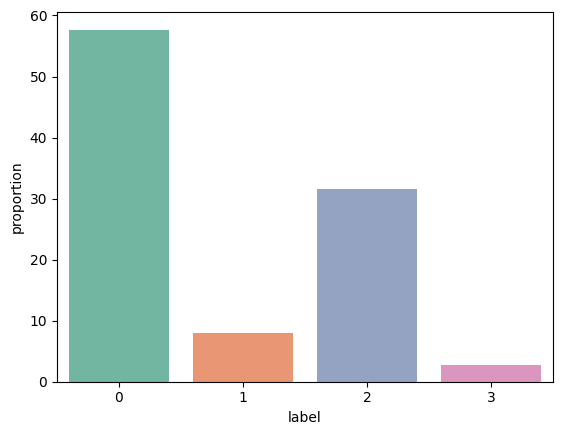

In [12]:
#Proporation of Label
label=train['label'].value_counts(normalize=True) *100
print(label)
sns.barplot(label,palette='Set2')

**Label Distribution**
* Label 0 dominates at 57.66% (over half the data), making it the easy-to-predict majority class.
* Label 2 is secondary at 31.54%, together with 0 covering ~89% of samples.
* Labels 1 (8.04%) and 3 (2.76%) are present in very less.
* This shows class imbalance. To overcome this we need to use stratified k-fold or Smote oversampling,

<Axes: xlabel='downvote', ylabel='Count'>

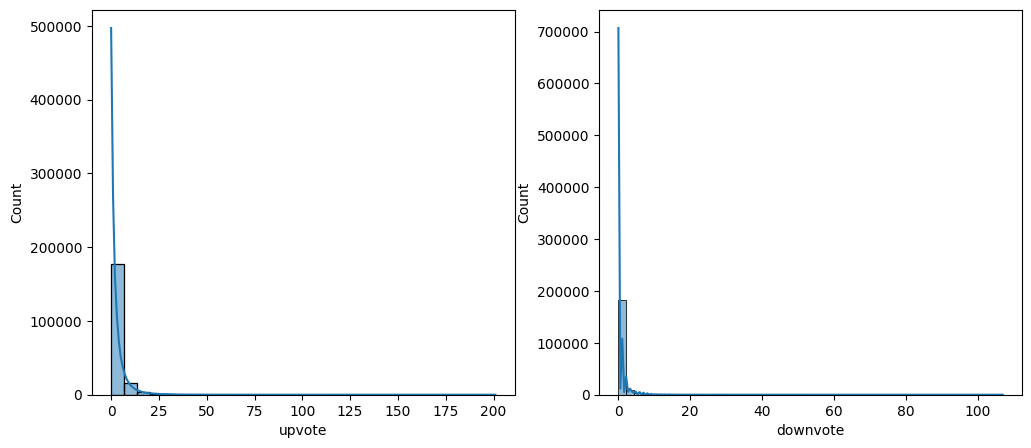

In [13]:
#Plot of Upvote and Downvote using bins 
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(data=train, x='upvote', bins=30, kde=True)
plt.subplot(1,2,2)
sns.histplot(data=train,x='downvote',bins=50,kde=True)

Distribution patterns
* Upvotes and downvotes are extremely skewed: the vast majority of comments have very low upvote/downvote counts, with a long tail of a few   comments having high values.

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'none'),
  Text(1, 0, 'white'),
  Text(2, 0, 'other'),
  Text(3, 0, 'asian'),
  Text(4, 0, 'black'),
  Text(5, 0, 'latino')])

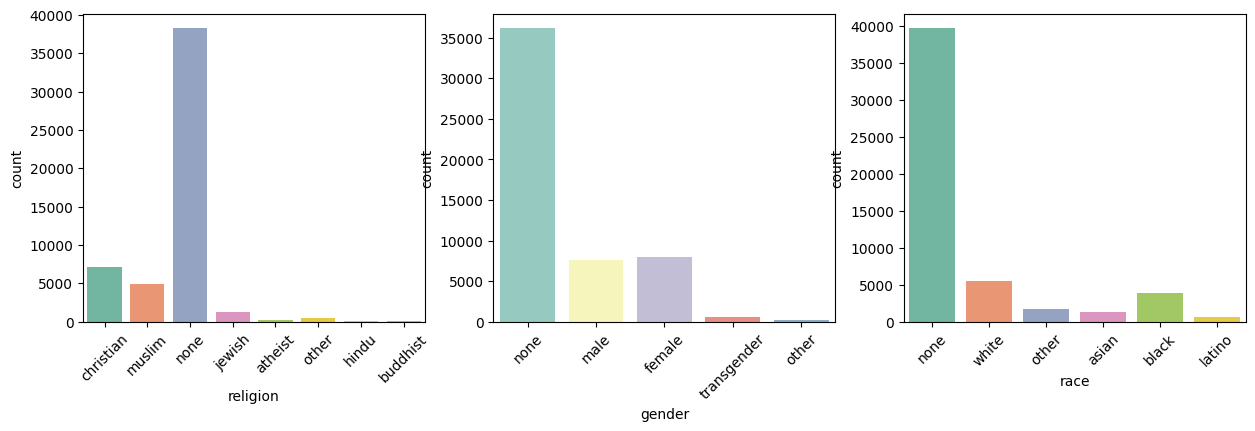

In [14]:
#Plot of Gender,Race and Religion
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.countplot(data=train, x='religion',palette='Set2')
plt.xticks(rotation=45)

plt.subplot(1,3,2)
sns.countplot(data=train,x='gender',palette='Set3')
plt.xticks(rotation=45)

plt.subplot(1,3,3)
sns.countplot(data=train,x='race',palette='Set2')
plt.xticks(rotation=45)

Category breakdowns
* Religion: Massive "none/other" dominance (~30k+ counts, blue bar); Christians (~20k, green) and Muslims (~15k, yellow) next; Jews/Hindus/Buddhists very rare (<5k).
* Gender: "None" largest (~30k); Male/Female balanced ~15-20k each; Transgender/Other minimal (~1-2k).
* Race: Whites overwhelmingly dominant (~30k+); Blacks/Asians/Hispanics/Latinos much smaller (5-15k); others negligible
* High Presence of None suggests us to replace it with something.

<Axes: >

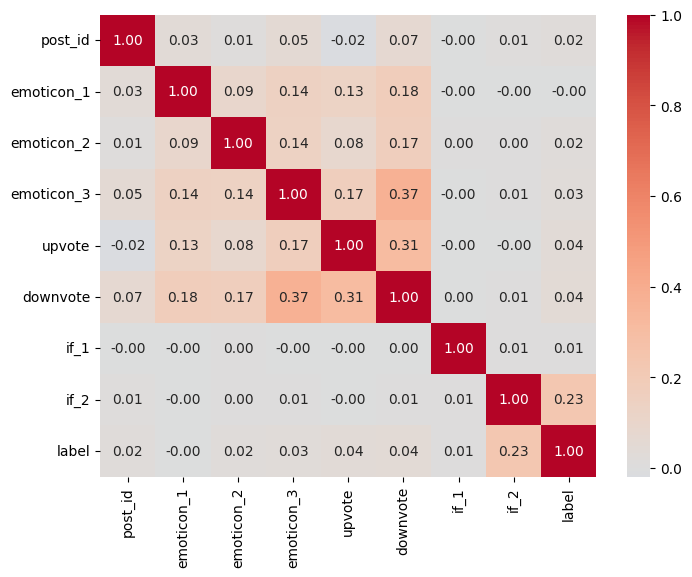

In [15]:
#Correlation Matrix
plt.figure(figsize=(8,6))
num_cols = train.select_dtypes(include=['int','float']).columns
corr_matrix = train[num_cols].corr()
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap="coolwarm",center=0)

**Correlation Matrix Interpretation**
 * Overall, there is no strong linear correlation between most features and the target label; all correlations with label are very small in magnitude.

* if_2 has the highest positive correlation with label (around 0.23), so this feature is the most informative among the shown variables, but still only weakly related.

* downvote and upvote are moderately correlated with each other (about 0.31), which means posts that get more upvotes also tend to get more downvotes.

* emoticon_3 shows a moderate positive correlation with downvote (around 0.37), suggesting comments using that emoticon pattern may attract more downvotes.

* Other features (post_id, emoticon_1, emoticon_2, if_1) have near-zero correlations with both label and with each other, so they may add limited predictive power in a linear sense.

**Preprocessing**

In [16]:
#Fill nan values in comment with empty string 
train['comment'] = train['comment'].fillna("")
test['comment']= test['comment'].fillna("")

In [17]:
#Replaces NaN value with no_preference
cols = ['race', 'religion', 'gender']
for col in cols:
    train[col] = train[col].fillna('Unknown')
    test[col] = test[col].fillna('Unknown')

In [18]:
train['disability']=train['disability'].astype(int)
test['disability']=test['disability'].astype(int)

In [19]:
#Creates new column comment_length which captures length of comment.
train['comment_length']=train['comment'].str.len()
test['comment_length']=test['comment'].str.len()
train.groupby('label')['comment_length'].mean()

label
0    295.897252
1    335.709700
2    316.893418
3    194.171695
Name: comment_length, dtype: float64

In [20]:
#Creates vote_diff and vote_ratio using upvote and downvote columns
for df in [train, test]:
    df['vote_diff'] = df['upvote'] - df['downvote']
    df['vote_ratio'] = df['upvote'] / (df['downvote'] + 1)
    df['upvote_diff']=df['vote_diff'] / (df['upvote'] +1)
    df['downvote_diff']=df['vote_diff'] / (df['downvote'] +1)
    df['upVote_comment_length']= df['comment_length'] / (df['upvote'] +1)
    df['downVote_comment_length']= df['comment_length'] / (df['downvote'] +1)

In [21]:
#Converts date into python compatible date in training and test data
train['created_date']=pd.to_datetime(train['created_date'])
test['created_date']=pd.to_datetime(test['created_date'])

for df in [train,test]:
    df['year']=df['created_date'].dt.year
    df['month']=df['created_date'].dt.month
    df['day'] = df['created_date'].dt.day
train.drop('created_date',axis=1,inplace=True)
test.drop('created_date',axis=1,inplace=True)

In [22]:
train['month'].value_counts()

month
5     23573
3     21280
4     20143
2     19526
1     18983
12    15309
8     14223
10    13925
6     13426
11    13417
9     12373
7     11822
Name: count, dtype: int64

In [23]:
#Sum of Emoticon
train['total_emoticon']=train['emoticon_1'] + train['emoticon_2'] + train['emoticon_3']
test['total_emoticon']=test['emoticon_1'] + test['emoticon_2'] + test['emoticon_3']

In [24]:
#Sum of if
train['sum_if']=train['if_1']+train['if_2']
test['sum_if']=test['if_1']+test['if_2']

In [25]:
train['total_emoticon'].unique()

array([ 0,  2,  1, 16,  3,  4,  5,  6, 11,  7,  8, 12, 24, 15,  9, 10, 18,
       13, 19, 20, 26, 22, 17, 14, 21, 37, 41, 30, 28, 39, 23, 60, 32, 50,
       25, 36, 27, 34, 35])

<Axes: >

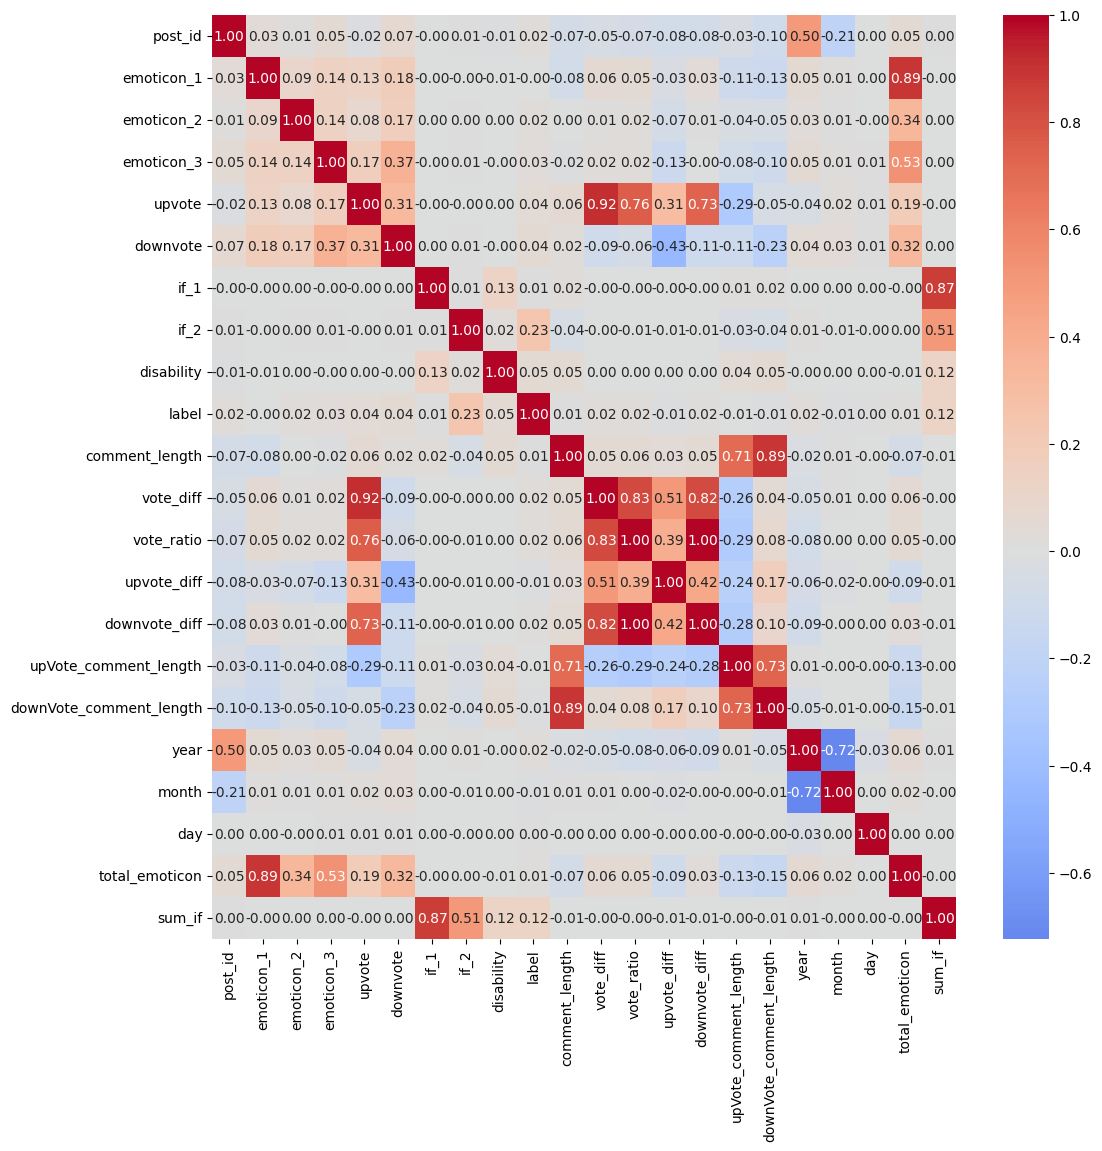

In [26]:
plt.figure(figsize=(12,12))
num_cols = train.select_dtypes(include=['int','float']).columns
corr_matrix = train[num_cols].corr()
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap="coolwarm",center=0)

In [27]:
#Instatinate Tfidf Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(max_features=30000,ngram_range=(1,2),stop_words='english',min_df=5,max_df=0.9,sublinear_tf=True)

In [28]:
#Features and Label Separation
X=train.drop(['label','post_id'],axis=1)
y=train['label']

In [29]:
#Column Transformer and Standard Scaler 
from sklearn.decomposition import TruncatedSVD
num_cols = X.select_dtypes(include=['int','float']).columns.tolist()
cat_cols= ['race','religion','gender']
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler,RobustScaler,MinMaxScaler
preprocessor=ColumnTransformer([
    ('cat',OneHotEncoder(handle_unknown='ignore'),cat_cols),
    ('text',tfidf,'comment'),
    ('num',StandardScaler(),num_cols)
    
])

In [30]:
X=preprocessor.fit_transform(X)
test=preprocessor.transform(test)

In [31]:
"""
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=300)
X = svd.fit_transform(X)
test = svd.transform(test) """

'\nfrom sklearn.decomposition import TruncatedSVD\n\nsvd = TruncatedSVD(n_components=300)\nX = svd.fit_transform(X)\ntest = svd.transform(test) '

In [32]:
#Model Imports 
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC,SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix

In [33]:
#Train-Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [34]:
#Baseline Model Logistic Regression
lr=LogisticRegression(C=1.5,random_state=42)
lr.fit(X_train,y_train)


LogisticRegression(C=1.5, random_state=42)

In [35]:
y_train_pred=lr.predict(X_train)
train_ac=accuracy_score(y_train,y_train_pred)
print(train_ac)
y_pred = lr.predict(X_test)
logistic_ac=accuracy_score(y_test,y_pred)
print(classification_report(y_test, y_pred))

0.9036237373737374
              precision    recall  f1-score   support

           0       0.96      0.94      0.95     22835
           1       0.77      0.71      0.74      3183
           2       0.84      0.90      0.87     12488
           3       0.68      0.41      0.51      1094

    accuracy                           0.90     39600
   macro avg       0.81      0.74      0.77     39600
weighted avg       0.90      0.90      0.90     39600



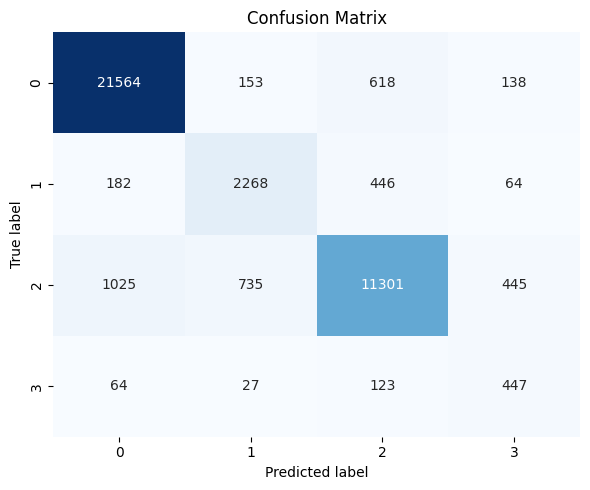

In [36]:
cm=confusion_matrix(y_pred,y_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show() 

In [37]:
"""
#SGD Classifier 
clf = SGDClassifier(loss="hinge", penalty="l1")
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
sgd_ac=accuracy_score(y_test,y_pred)
print(classification_report(y_test, y_pred)) """

'\n#SGD Classifier \nclf = SGDClassifier(loss="hinge", penalty="l1")\nclf.fit(X_train, y_train)\n\ny_pred = clf.predict(X_test)\nsgd_ac=accuracy_score(y_test,y_pred)\nprint(classification_report(y_test, y_pred)) '

In [38]:
"""
#LGBM Classifier
lgbm=LGBMClassifier(objective='multiclass',
    num_class=4, 
    learning_rate=0.1)
lgbm.fit(X_train,y_train)
y_pred = lgbm.predict(X_test)
lgbm_ac=accuracy_score(y_test,y_pred)
print(classification_report(y_test, y_pred)) """

"\n#LGBM Classifier\nlgbm=LGBMClassifier(objective='multiclass',\n    num_class=4, \n    learning_rate=0.1)\nlgbm.fit(X_train,y_train)\ny_pred = lgbm.predict(X_test)\nlgbm_ac=accuracy_score(y_test,y_pred)\nprint(classification_report(y_test, y_pred)) "

In [39]:
"""
#AdaBoost
ada = AdaBoostClassifier(
    random_state=2306)

ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)
ada_ac=accuracy_score(y_test,y_pred)
print(ada_ac)
print(classification_report(y_test, y_pred)) """

'\n#AdaBoost\nada = AdaBoostClassifier(\n    random_state=2306)\n\nada.fit(X_train, y_train)\ny_pred = ada.predict(X_test)\nada_ac=accuracy_score(y_test,y_pred)\nprint(ada_ac)\nprint(classification_report(y_test, y_pred)) '

In [40]:
"""
mlp = MLPClassifier(
    hidden_layer_sizes=(128,64,32),
    activation="relu",
    solver="adam",
    max_iter=5,
    batch_size=32,
    random_state=2306
)

mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
mlp_ac=accuracy_score(y_test,y_pred)
print(mlp_ac)
total_samples = cm.sum()
misclassified = total_samples - np.trace(cm)
result = misclassified / total_samples
print(round(result,4)) """

'\nmlp = MLPClassifier(\n    hidden_layer_sizes=(128,64,32),\n    activation="relu",\n    solver="adam",\n    max_iter=5,\n    batch_size=32,\n    random_state=2306\n)\n\nmlp.fit(X_train, y_train)\ny_pred = mlp.predict(X_test)\n\ncm = confusion_matrix(y_test, y_pred)\nmlp_ac=accuracy_score(y_test,y_pred)\nprint(mlp_ac)\ntotal_samples = cm.sum()\nmisclassified = total_samples - np.trace(cm)\nresult = misclassified / total_samples\nprint(round(result,4)) '

In [41]:
"""
#Linear SVC
svc=LinearSVC()
svc.fit(X_train,y_train)
y_pred=svc.predict(X_test)
print(classification_report(y_test,y_pred))
svc_ac=accuracy_score(y_train,y_pred)"""

'\n#Linear SVC\nsvc=LinearSVC()\nsvc.fit(X_train,y_train)\ny_pred=svc.predict(X_test)\nprint(classification_report(y_test,y_pred))\nsvc_ac=accuracy_score(y_train,y_pred)'

In [42]:
"""
#Random Forest
rfc=RandomForestClassifier()
rfc.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
randomforest_ac=accuracy_score(y_test,y_pred) """

'\n#Random Forest\nrfc=RandomForestClassifier()\nrfc.fit(X_train,y_train)\ny_pred = clf.predict(X_test)\nprint(classification_report(y_test, y_pred))\nrandomforest_ac=accuracy_score(y_test,y_pred) '

In [43]:
'''
#Hyper Parameter Tuning of Logistic Regression
param_grid = {
    'C': [0.1, 1,4,5,8, 10],
    'max_iter': [300,500,1000,1500,3000,5000],
    'solver': ['liblinear'],
    'class_weight': ['balanced']
}

lr = LogisticRegression(
    random_state=42)

grid = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    scoring='f1_macro',   
    cv=3,
    verbose=2,
    n_jobs=-1
)
grid.fit(X_train, y_train)

y_pred = grid.predict(X_test)
print(classification_report(y_test, y_pred))
hpt_logistic_ac=accuracy_score(y_test,y_pred)
print(hpt_logistic_ac)
print(grid.best_estimator_)
'''

"\n#Hyper Parameter Tuning of Logistic Regression\nparam_grid = {\n    'C': [0.1, 1,4,5,8, 10],\n    'max_iter': [300,500,1000,1500,3000,5000],\n    'solver': ['liblinear'],\n    'class_weight': ['balanced']\n}\n\nlr = LogisticRegression(\n    random_state=42)\n\ngrid = GridSearchCV(\n    estimator=lr,\n    param_grid=param_grid,\n    scoring='f1_macro',   \n    cv=3,\n    verbose=2,\n    n_jobs=-1\n)\ngrid.fit(X_train, y_train)\n\ny_pred = grid.predict(X_test)\nprint(classification_report(y_test, y_pred))\nhpt_logistic_ac=accuracy_score(y_test,y_pred)\nprint(hpt_logistic_ac)\nprint(grid.best_estimator_)\n"

In [44]:
"""
#Hyper Parameter Tuning LGBM
param_dist = {
    'n_estimators': [500, 1000,1500,2000],
    'learning_rate': [0.01, 0.05, 0.1,0.2,0.3],
    'num_leaves': [31, 50, 70,80,90],
    'max_depth': [7, 10, 15,20,25,30],
    'feature_fraction': [0.7, 0.8, 0.9],
    'min_child_samples': [20, 50, 100,150,180,200]
}


lgbm = LGBMClassifier(objective='multiclass', num_class=4, random_state=42)

random_search = RandomizedSearchCV(
    lgbm, 
    param_distributions=param_dist, 
    n_iter=10, 
    cv=3, scoring='f1_macro', 
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_lgbm = random_search.best_estimator_
print(best_lgbm)
y_pred = best_lgbm.predict(X_test)
print(classification_report(y_test, y_pred))
hpt_lgbm_ac=accuracy_score(y_test,y_pred) """

"\n#Hyper Parameter Tuning LGBM\nparam_dist = {\n    'n_estimators': [500, 1000,1500,2000],\n    'learning_rate': [0.01, 0.05, 0.1,0.2,0.3],\n    'num_leaves': [31, 50, 70,80,90],\n    'max_depth': [7, 10, 15,20,25,30],\n    'feature_fraction': [0.7, 0.8, 0.9],\n    'min_child_samples': [20, 50, 100,150,180,200]\n}\n\n\nlgbm = LGBMClassifier(objective='multiclass', num_class=4, random_state=42)\n\nrandom_search = RandomizedSearchCV(\n    lgbm, \n    param_distributions=param_dist, \n    n_iter=10, \n    cv=3, scoring='f1_macro', \n    n_jobs=-1\n)\n\nrandom_search.fit(X_train, y_train)\n\nbest_lgbm = random_search.best_estimator_\nprint(best_lgbm)\ny_pred = best_lgbm.predict(X_test)\nprint(classification_report(y_test, y_pred))\nhpt_lgbm_ac=accuracy_score(y_test,y_pred) "

In [45]:
#Stacking Classifier
lr = LogisticRegression(C=1.5,max_iter=5000)
lgbm = LGBMClassifier(objective='multiclass',n_estimators=450,
                      num_class=4, 
                      learning_rate=0.05,
                      max_depth=8,
                      subsample=0.8,
                      colsample_bytree=0.8,
                      random_state=2306
                         )
svm = LinearSVC(C=0.05, class_weight='balanced')
stack = StackingClassifier(
    estimators=[
        
        ('lr', lr),
        ('lgb', lgbm),
        ('svm',svm)
    ],
    final_estimator=LogisticRegression(
        C=0.05,
        max_iter=2000
    ),
    cv=5,
    n_jobs=-1,
    passthrough=True
)


stack.fit(X_train,y_train)
y_pred=stack.predict(X_test)
print(classification_report(y_test, y_pred)) 
stack_ac=accuracy_score(y_test,y_pred)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 52.236620 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 913034
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 23547
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154061
[LightGBM] [Info] Start training from score -3.589217
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 18.436472 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 745976
[LightGBM] [Info] Number of data points in the train set: 126720, number of used features: 19388
[LightGBM] [Info] Start training from score -0.550548
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154076
[LightGBM] [Info] Start training from score -3.589217

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

In [46]:
"""
param_grid = {
    # Logistic Regression (base)
    'lr__C': [0.5, 1,1.5],

    # LightGBM
    'lgb__n_estimators': [50,100,200,300],
    'lgb__learning_rate': [0.01, 0.05,],
    'lgb__max_depth': [3, 5],

    # SVM
    'svm__C': [0.01, 0.1],

    # Final estimator
    'final_estimator__C': [0.001, 0.01, 0.1]
} """

"\nparam_grid = {\n    # Logistic Regression (base)\n    'lr__C': [0.5, 1,1.5],\n\n    # LightGBM\n    'lgb__n_estimators': [50,100,200,300],\n    'lgb__learning_rate': [0.01, 0.05,],\n    'lgb__max_depth': [3, 5],\n\n    # SVM\n    'svm__C': [0.01, 0.1],\n\n    # Final estimator\n    'final_estimator__C': [0.001, 0.01, 0.1]\n} "

In [47]:
"""
lr = LogisticRegression(max_iter=4000)
lgbm = LGBMClassifier(objective='multiclass',
                      num_class=4, 
                      subsample=0.8,
                      colsample_bytree=0.8,
                      random_state=2306
                         )
svm = LinearSVC(class_weight='balanced')

stack = StackingClassifier(
    estimators=[
        
        ('lr', lr),
        ('lgb', lgbm),
        ('svm',svm)
    ],
    final_estimator=LogisticRegression(
        max_iter=2000)) """

"\nlr = LogisticRegression(max_iter=4000)\nlgbm = LGBMClassifier(objective='multiclass',\n                      num_class=4, \n                      subsample=0.8,\n                      colsample_bytree=0.8,\n                      random_state=2306\n                         )\nsvm = LinearSVC(class_weight='balanced')\n\nstack = StackingClassifier(\n    estimators=[\n        \n        ('lr', lr),\n        ('lgb', lgbm),\n        ('svm',svm)\n    ],\n    final_estimator=LogisticRegression(\n        max_iter=2000)) "

In [48]:

"""
from sklearn.model_selection import RandomizedSearchCV

search = RandomizedSearchCV(
    estimator=stack,
    param_distributions=param_grid,
    n_iter=20,              # try 20 combinations
    scoring='accuracy',
    cv=3,                   # reduce from 5 → faster
    verbose=2,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)"""

"\nfrom sklearn.model_selection import RandomizedSearchCV\n\nsearch = RandomizedSearchCV(\n    estimator=stack,\n    param_distributions=param_grid,\n    n_iter=20,              # try 20 combinations\n    scoring='accuracy',\n    cv=3,                   # reduce from 5 → faster\n    verbose=2,\n    n_jobs=-1,\n    random_state=42\n)\n\nsearch.fit(X_train, y_train)"

In [49]:

"""best_stack = search.best_estimator_

y_pred = best_stack.predict(X_test)

from sklearn.metrics import classification_report, accuracy_score

print(classification_report(y_test, y_pred))
print("Best Accuracy:", accuracy_score(y_test, y_pred))"""

'best_stack = search.best_estimator_\n\ny_pred = best_stack.predict(X_test)\n\nfrom sklearn.metrics import classification_report, accuracy_score\n\nprint(classification_report(y_test, y_pred))\nprint("Best Accuracy:", accuracy_score(y_test, y_pred))'

In [50]:
"""
cm = confusion_matrix(y_test, y_pred)
total_samples = cm.sum()
misclassified = total_samples - np.trace(cm)
result = misclassified / total_samples
print(round(result,4))"""

'\ncm = confusion_matrix(y_test, y_pred)\ntotal_samples = cm.sum()\nmisclassified = total_samples - np.trace(cm)\nresult = misclassified / total_samples\nprint(round(result,4))'

In [51]:
model={
    'logistic_regression':0.785,
    'sgd_classifier': 0.696,
    'LGBM': 0.796,
    'SVC': 0.668,
    'MLP': 0.182,
    'HPT_LogisticRegression': 0.794,
    'HPT_LGBM':0.802,
    'stackingClassifier': 0.81
}
df = pd.DataFrame(list(model.items()), columns=['Model','Accuracy'])

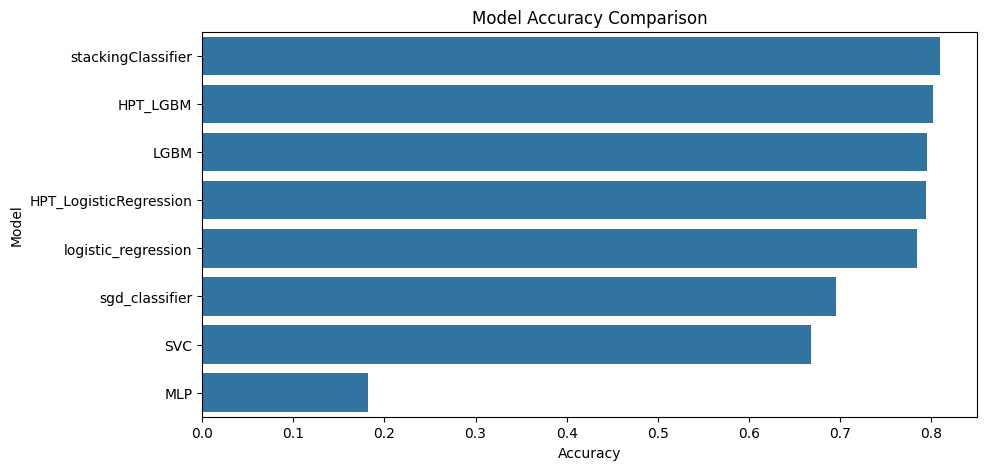

In [52]:
df = df.sort_values(by="Accuracy", ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x='Accuracy', y='Model', data=df)
plt.title("Model Accuracy Comparison")
plt.show()

**Model Insight**
* StackingClassifier achieved the highest accuracy (~0.809), showing that combining multiple models improves predictive performance compared to individual models.
* Hyperparameter tuning improved model performance, as seen in both Logistic Regression and LightGBM where the tuned versions performed better than their default configurations.
* LightGBM-based models performed consistently well, indicating that gradient boosting methods are effective for this dataset.
* Traditional linear models like Logistic Regression still performed competitively, achieving accuracy close to the best models after tuning.
* MLP performed poorly (~0.18 accuracy), suggesting that the neural network architecture or training setup was not suitable for the dataset or required further tuning.

In [53]:
#Predication on test data and submission
test_preds = stack.predict(test)
submission = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")
submission['label'] = test_preds
submission.to_csv("submission.csv", index=False)